# Laboratorio Final — Starbucks Rewards: del experimento a la decisión

Cierra el bloque de Churn y Uplift Modeling. Van a trabajar con la campaña COMPLETA (no una
muestra de prueba): 40,000 clientes, mitad recibió un cupón de $5 (tratamiento), mitad no
(control), medidos a 60 días.

Este laboratorio repite, sobre la base completa, lo que ya practicaron en los Breakout Rooms:

| Dónde lo vieron | Qué van a repetir aquí |
|---|---|
| Breakout 2 — Las dos ventanas | Un modelo de riesgo/churn, para targetear y ver la pérdida |
| Breakout 3 — Los 4 cuadrantes | El T-learner: dos modelos, uno por grupo |
| Breakout 4 — La curva Qini | Miden qué tan bien ordena su T-learner con datos que nunca vio |

Las columnas `recency_days`, `frequency` y `monetary` son las mismas del RFM de la Semana 1.

**Los 3 pasos del laboratorio:**
1. Entrenan un modelo de churn y lo usan para targetear — van a ver la pérdida con sus
   propios números.
2. Programan el T-learner y miden su Qini.
3. Deciden a quién contactar: eligen el porcentaje óptimo y defienden la cifra.

El dataset trae una columna oculta con el **tipo real de cada cliente y su uplift
verdadero** — en la vida real esa columna no existe. Al final del laboratorio la van a
destapar para ver si sus modelos acertaron.

Donde dice **`# TODO`** hay algo para que ustedes completen.


In [1]:
!git clone https://github.com/CristianFGC12/marketing-analytics-cristian-gonzalez.git
%cd marketing-analytics-cristian-gonzalez/Semana_3/Tarea
!pip install -r requirements.txt

Cloning into 'marketing-analytics-cristian-gonzalez'...
remote: Enumerating objects: 94, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 94 (delta 43), reused 35 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (94/94), 2.73 MiB | 16.53 MiB/s, done.
Resolving deltas: 100% (43/43), done.
/content/marketing-analytics-cristian-gonzalez/Semana_3/Tarea
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 947.5/947.5 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.2/60.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 30.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/uplift_campaign.csv")
print(f"{len(df):,} clientes · {(df['treatment_group']=='treatment').sum():,} tratados · {(df['treatment_group']=='control').sum():,} control")
df.head()


40,000 clientes · 19,921 tratados · 20,079 control


,customer_id,treatment_group,recency_days,frequency,monetary,email_open_rate,tenure_days,responded_60d,value_60d,margin_60d,utilidad_neta_60d
0,1,treatment,15,25,615.42,0.230,998,1,38.86,9.72,4.67
1,2,control,30,7,196.12,0.231,551,1,57.20,14.30,14.30
2,3,control,37,1,151.60,0.428,508,0,0.00,0.00,0.00
3,4,control,0,16,449.54,0.386,733,1,24.21,6.05,6.05
4,5,treatment,20,10,393.00,0.796,734,1,23.62,5.91,0.86


## Paso 1 — entrenen un modelo de churn y usen para targetear

Un modelo de churn normal: no sabe nada de tratamiento/control, solo aprende a predecir quién
NO va a volver a comprar. Lo van a usar para elegir a quién contactar (targeting por riesgo) y
van a medir qué tan bien o mal les fue con esa decisión, usando el experimento real como juez.


In [3]:
FEATURES = ["recency_days", "frequency", "monetary", "email_open_rate", "tenure_days"]

train, test = train_test_split(df, test_size=0.30, random_state=42, stratify=df["treatment_group"])

train_churn = train.copy()
train_churn["churned"] = 1 - train_churn["responded_60d"]

# TODO: entrenen el modelo de riesgo/churn con SOLO los datos de entrenamiento
modelo_riesgo = LogisticRegression(max_iter=1000)  # <-- reemplacen esto: LogisticRegression(max_iter=1000).fit(X, y)
modelo_riesgo.fit(train_churn[FEATURES],train_churn["churned"])

test = test.copy()
test["prob_churn"] = modelo_riesgo.predict_proba(test[FEATURES])[:, 1]
print("Modelo de riesgo entrenado")


Modelo de riesgo entrenado


Ahora midan el valor real de targetear por riesgo: tomen el 30% con mayor probabilidad de
churn en el conjunto de prueba, y comparen el valor neto (`utilidad_neta_60d` para los
tratados de ese grupo, contra `margin_60d` del control de ese mismo grupo — su "costo de no
hacer nada").


In [4]:
def valor_de_la_politica(test_df, seleccionados):
    # Valor NETO: margen bruto menos el costo del cupón ($5, solo si compró) y el envío
    # ($0.05, por cualquier tratado) -- la misma fórmula de la slide "El experimento".
    sel = test_df.loc[seleccionados]
    valor_tratado = sel.loc[sel["treatment_group"] == "treatment", "utilidad_neta_60d"].mean()
    valor_control = sel.loc[sel["treatment_group"] == "control", "margin_60d"].mean()
    return valor_tratado - valor_control, len(sel)

n_contactar = int(len(test) * 0.30)
idx_riesgo = test.sort_values("prob_churn", ascending=False).head(n_contactar).index
uplift_riesgo, n_riesgo = valor_de_la_politica(test, idx_riesgo)
print(f"Targeting por riesgo: ${uplift_riesgo:+.2f}/cliente sobre {n_riesgo:,} clientes (total ${uplift_riesgo*n_riesgo:+,.2f})")


Targeting por riesgo: $+0.07/cliente sobre 3,600 clientes (total $+245.40)


## Paso 2 — programen el T-learner y midan su Qini

Dos modelos de **Regresión Logística**: uno entrenado SOLO con los clientes tratados de entrenamiento, otro SOLO con los
de control. Le preguntan a los dos sobre el conjunto de prueba completo, y restan.


In [5]:
train_t = train[train["treatment_group"] == "treatment"]
train_c = train[train["treatment_group"] == "control"]

# TODO: entrenen los dos modelos del T-learner
modelo_tratado = LogisticRegression(max_iter=1000).fit(train_t[FEATURES],train_t["responded_60d"])  # <-- reemplacen esto
modelo_control = LogisticRegression(max_iter=1000).fit(train_c[FEATURES],train_c["responded_60d"])   # <-- reemplacen esto

X_test = test[FEATURES]
# TODO: puntúen el conjunto de prueba con los dos modelos y calculen el uplift estimado
test["p_tratado"] = modelo_tratado.predict_proba(X_test)[:, 1]       # <-- reemplacen esto
test["p_control"] = modelo_control.predict_proba(X_test)[:, 1]        # <-- reemplacen esto
test["uplift_estimado"] = test["p_tratado"] - test["p_control"]

print("T-learner entrenado y conjunto de prueba puntuado")


T-learner entrenado y conjunto de prueba puntuado


In [6]:
def curva_qini(test_df, score_col, steps=40):
    orden = test_df.sort_values(score_col, ascending=False).reset_index(drop=True)
    es_tratado = (orden["treatment_group"] == "treatment").values
    respondio = orden["responded_60d"].values

    acumulado_tratados = np.cumsum(np.where(es_tratado, respondio, 0))
    acumulado_control = np.cumsum(np.where(~es_tratado, respondio, 0))
    n_tratados_acum = np.cumsum(es_tratado)
    n_control_acum = np.cumsum(~es_tratado)

    n = len(orden)
    xs, ys = [0.0], [0.0]
    for i in np.linspace(1, n, steps).astype(int):
        nt, nc = n_tratados_acum[i - 1], n_control_acum[i - 1]
        tasa_t = acumulado_tratados[i - 1] / nt if nt > 0 else 0
        tasa_c = acumulado_control[i - 1] / nc if nc > 0 else 0
        xs.append(i / n)
        ys.append((tasa_t - tasa_c) * n)
    return np.array(xs), np.array(ys)


def coeficiente_qini(xs, ys, n):
    area_modelo = np.trapezoid(ys, xs)
    area_azar = np.trapezoid(np.linspace(0, ys[-1], len(xs)), xs)
    return (area_modelo - area_azar) / n


xs_uplift, ys_uplift = curva_qini(test, "uplift_estimado")
xs_riesgo, ys_riesgo = curva_qini(test, "prob_churn")
qini_uplift = coeficiente_qini(xs_uplift, ys_uplift, len(test))
qini_riesgo = coeficiente_qini(xs_riesgo, ys_riesgo, len(test))

print(f"Coeficiente Qini · T-learner:       {qini_uplift:+.3f}")
print(f"Coeficiente Qini · riesgo/churn:    {qini_riesgo:+.3f}")


Coeficiente Qini · T-learner:       +0.142
Coeficiente Qini · riesgo/churn:    +0.048


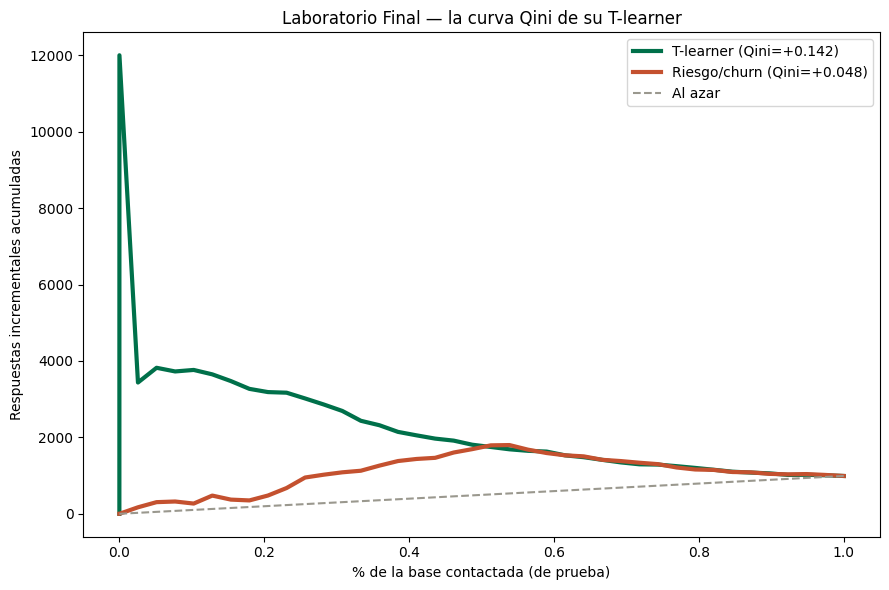

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(xs_uplift, ys_uplift, color="#00704A", linewidth=3, label=f"T-learner (Qini={qini_uplift:+.3f})")
ax.plot(xs_riesgo, ys_riesgo, color="#C4512F", linewidth=3, label=f"Riesgo/churn (Qini={qini_riesgo:+.3f})")
ax.plot([0, 1], [0, ys_uplift[-1]], color="#9A988E", linestyle="--", label="Al azar")
ax.set_xlabel("% de la base contactada (de prueba)")
ax.set_ylabel("Respuestas incrementales acumuladas")
ax.set_title("Laboratorio Final — la curva Qini de su T-learner")
ax.legend()
plt.tight_layout()
plt.savefig("curva_qini_laboratorio.png", dpi=150)
plt.show()


## Paso 3 — decidan a quién contactar

Prueben varios porcentajes de la base (10%, 20%, ..., 100%) ordenados por `uplift_estimado`, y
para cada uno calculen el valor neto total (usando `value_60d`, igual que en el Paso 2).
Encuentren el porcentaje que deja más dinero sobre la mesa.


In [8]:
resultados = []
for pct in range(10, 101, 10):
    n_c = int(len(test) * pct / 100)
    idx = test.sort_values("uplift_estimado", ascending=False).head(n_c).index
    valor_cliente, n = valor_de_la_politica(test, idx)
    resultados.append({"pct_contactado": pct, "valor_por_cliente": round(valor_cliente, 2), "n_contactados": n, "valor_total": round(valor_cliente * n, 2)})

tabla_politicas = pd.DataFrame(resultados)
tabla_politicas


,pct_contactado,valor_por_cliente,n_contactados,valor_total
0,10,1.62,1200,1948.93
1,20,0.99,2400,2368.51
2,30,0.46,3600,1673.33
3,40,-0.10,4800,-500.97
4,50,-0.48,6000,-2899.72
5,60,-0.73,7200,-5260.88
6,70,-0.93,8400,-7853.02
7,80,-1.17,9600,-11226.84
8,90,-1.45,10800,-15687.26
9,100,-1.69,12000,-20236.13


**Pregunta para defender con su propia cifra:** ¿cuál % maximiza el valor TOTAL? ¿Es el mismo
que maximiza el valor POR CLIENTE? ¿Por qué no, necesariamente?

**Respuesta:** El 20% es el que maximiza el valor total, pero no es el mismo que maximiza el valor por cliente. Esto se debe a que si bien el 10% tiene un multiplicador mayor este se aplica sobre una cantidad menor de los mismo.


## La revelación final

Esta es la parte que no pudieron hacer en los Breakout Rooms: el dataset completo
(`uplift_campaign_FULL.csv`) trae el **tipo real** de cada cliente y su **uplift verdadero** —
información que en la vida real nunca existe. Compárenla contra lo que su modelo estimó.


In [9]:
full = pd.read_csv("uplift_campaign_FULL.csv")
full_test = full[full["customer_id"].isin(test["customer_id"])].merge(
    test[["customer_id", "uplift_estimado", "prob_churn"]], on="customer_id"
)

print("Composición real de la base de prueba:")
print((full_test["true_type"].value_counts(normalize=True) * 100).round(1))
print()
print("Correlación entre uplift ESTIMADO y uplift VERDADERO:", round(full_test["uplift_estimado"].corr(full_test["true_uplift_prob"]), 3))


Composición real de la base de prueba:
true_type
sure_thing      48.9
persuadable     22.4
lost_cause      21.5
sleeping_dog     7.2
Name: proportion, dtype: float64

Correlación entre uplift ESTIMADO y uplift VERDADERO: 0.619


## Para entregar

1. El notebook completo, ejecutado de principio a fin, con sus respuestas a las preguntas de
   cada paso.
2. **Su propia app de Streamlit** (usen `streamlit_starter.py` como punto de partida) que le
   permita a alguien de negocio explorar: el Qini del T-learner y la tabla de
   políticas del Paso 3 — con al menos un control interactivo (slider o selector).
3. Una conclusión de una página: ¿a qué porcentaje de la base contactarían, y por qué? Usen la
   comparación final para decir qué tan cerca estuvo su modelo de la verdad.
4. Cambien el modelo base del T-learner (Árbol de decisión, Random Forest, Gradient Boosting, SVM…) y comparen contra la logística. Cuiden el sobreajuste, por ejemplo con max_depth o min_samples_leaf. ¿Cuál mejora más la correlación del Uplift y el Qini index?


In [10]:
from sklearn.tree import DecisionTreeClassifier

#Arbol de Decisión profundidad 3

modelo_tratado_arbol = DecisionTreeClassifier(max_depth=3,min_samples_leaf=100,random_state=42)

modelo_control_arbol = DecisionTreeClassifier(max_depth=3,min_samples_leaf=100,random_state=42)

modelo_tratado_arbol.fit(train_t[FEATURES],train_t["responded_60d"])

modelo_control_arbol.fit(train_c[FEATURES],train_c["responded_60d"])

DecisionTreeClassifier(max_depth=3, min_samples_leaf=100, random_state=42)

In [11]:
test["p_tratado_arbol"] = modelo_tratado_arbol.predict_proba(X_test)[:, 1]

test["p_control_arbol"] = modelo_control_arbol.predict_proba(X_test)[:, 1]

test["uplift_arbol"] = (test["p_tratado_arbol"] - test["p_control_arbol"])

In [12]:
xs_arbol, ys_arbol = curva_qini(test,"uplift_arbol")

qini_arbol = coeficiente_qini(xs_arbol,ys_arbol,len(test))

print(f"Qini Logística: {qini_uplift:+.3f}")
print(f"Qini Árbol:     {qini_arbol:+.3f}")

Qini Logística: +0.142
Qini Árbol:     +0.129


In [13]:
from sklearn.ensemble import RandomForestClassifier

#Random Forest
modelo_tratado_rf = RandomForestClassifier(n_estimators=200,max_depth=5,min_samples_leaf=50,random_state=42,n_jobs=-1)

modelo_control_rf = RandomForestClassifier(n_estimators=200,max_depth=5,min_samples_leaf=50,random_state=42,n_jobs=-1)

modelo_tratado_rf.fit(train_t[FEATURES],train_t["responded_60d"])

modelo_control_rf.fit(train_c[FEATURES],train_c["responded_60d"])

test["p_t_rf"] = modelo_tratado_rf.predict_proba(X_test)[:, 1]
test["p_c_rf"] = modelo_control_rf.predict_proba(X_test)[:, 1]

test["uplift_rf"] = test["p_t_rf"] - test["p_c_rf"]

xs_rf, ys_rf = curva_qini(test,"uplift_rf")
qini_rf = coeficiente_qini(xs_rf,ys_rf,len(test))

print(f"Qini Random_Forest:     {qini_rf:+.3f}")

Qini Random_Forest:     +0.157


In [21]:
full_test = full[full["customer_id"].isin(test["customer_id"])].merge(
    test[["customer_id", "uplift_arbol","uplift_rf","uplift_estimado", "prob_churn"]], on="customer_id"
)

print("Correlación entre uplift Arbol y uplift VERDADERO:", round(full_test["uplift_arbol"].corr(full_test["true_uplift_prob"]), 3))
print("Correlación entre uplift Random Forest y uplift VERDADERO:", round(full_test["uplift_rf"].corr(full_test["true_uplift_prob"]), 3))

Correlación entre uplift Arbol y uplift VERDADERO: 0.617
Correlación entre uplift Random Forest y uplift VERDADERO: 0.858


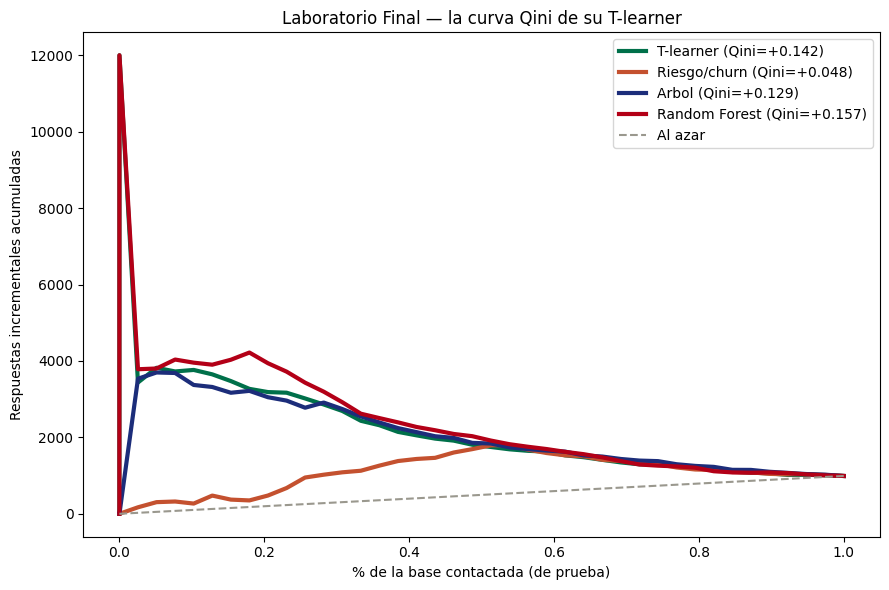

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(xs_uplift, ys_uplift, color="#00704A", linewidth=3, label=f"T-learner (Qini={qini_uplift:+.3f})")
ax.plot(xs_riesgo, ys_riesgo, color="#C4512F", linewidth=3, label=f"Riesgo/churn (Qini={qini_riesgo:+.3f})")
ax.plot(xs_arbol, ys_arbol, color="#1C2D7A", linewidth=3, label=f"Arbol (Qini={qini_arbol:+.3f})")
ax.plot(xs_rf, ys_rf, color="#B30017", linewidth=3, label=f"Random Forest (Qini={qini_rf:+.3f})")
ax.plot([0, 1], [0, ys_uplift[-1]], color="#9A988E", linestyle="--", label="Al azar")
ax.set_xlabel("% de la base contactada (de prueba)")
ax.set_ylabel("Respuestas incrementales acumuladas")
ax.set_title("Laboratorio Final — la curva Qini de su T-learner")
ax.legend()
plt.tight_layout()
plt.savefig("curva_qini_laboratorio.png", dpi=150)
plt.show()


De los modelos probados con el T-Learner, el que mejoro tanto el uplift como el qini fue el Random Forest.

In [25]:
comparacion = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "Árbol con max_depth 3",
        "Random Forest"
    ],
    "Correlación Uplift con Real": [
        round(full_test["uplift_estimado"].corr(full_test["true_uplift_prob"]), 3),
        round(full_test["uplift_arbol"].corr(full_test["true_uplift_prob"]), 3),
        round(full_test["uplift_rf"].corr(full_test["true_uplift_prob"]), 3)
    ],
    "Qini": [
        f"{qini_uplift:+.3f}",
        f"{qini_arbol:+.3f}",
        f"{qini_rf:+.3f}"
        ]
    })

comparacion

,Modelo,Correlación Uplift con Real,Qini
0,Regresión Logística,0.619,+0.142
1,Árbol con max_depth 3,0.617,+0.129
2,Random Forest,0.858,+0.157
